# iDLG Attack Analysis: PSNR Distributions & Convergence Rate
Loads `idlg_results_export.json` and produces:
- Box plots of PSNR per defence condition
- Bar chart of iterations needed to reach PSNR thresholds

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
%matplotlib inline

with open('idlg_results_export.json') as f:
    idlg_json = json.load(f)

ALPHAS     = [1, 0.99, 0.98, 0.97, 0.96, 0.95, 0.94, 0.93, 0.92, 0.91, 0.90, 0.05, 0.0]
SEEDS      = [10, 20, 30]
N_IMAGES   = 30
N_RESTARTS = 5
FS         = 10


def get_best_psnr_per_image(method, alpha):
    vals = []
    for seed in SEEDS:
        for img in range(N_IMAGES):
            best_p = np.nan
            for r in range(N_RESTARTS):
                key   = f'{method}_{alpha:.2f}_{seed}_{img}_{r}'
                entry = idlg_json.get(key)
                if entry and entry.get('psnr'):
                    p = entry['psnr'][-1]
                    if np.isnan(best_p) or p > best_p:
                        best_p = p
            if not np.isnan(best_p):
                vals.append(best_p)
    return vals


def get_mean_psnr_curve(method, alpha):
    curves = []
    for seed in SEEDS:
        for img in range(N_IMAGES):
            best_p, best_curve = np.nan, None
            for r in range(N_RESTARTS):
                key   = f'{method}_{alpha:.2f}_{seed}_{img}_{r}'
                entry = idlg_json.get(key)
                if entry and entry.get('psnr'):
                    p = entry['psnr'][-1]
                    if np.isnan(best_p) or p > best_p:
                        best_p     = p
                        best_curve = np.array(entry['psnr'])
            if best_curve is not None:
                curves.append(best_curve)
    if not curves:
        return None
    max_len = max(len(c) for c in curves)
    mat = np.full((len(curves), max_len), np.nan)
    for i, c in enumerate(curves):
        mat[i, :len(c)] = c
        mat[i, len(c):] = c[-1]
    return np.nanmean(mat, axis=0)


def iters_to_threshold(curve, threshold):
    if curve is None:
        return np.nan
    idx = np.where(curve >= threshold)[0]
    return int(idx[0]) if len(idx) > 0 else len(curve)

## PSNR Distribution per Defence Condition

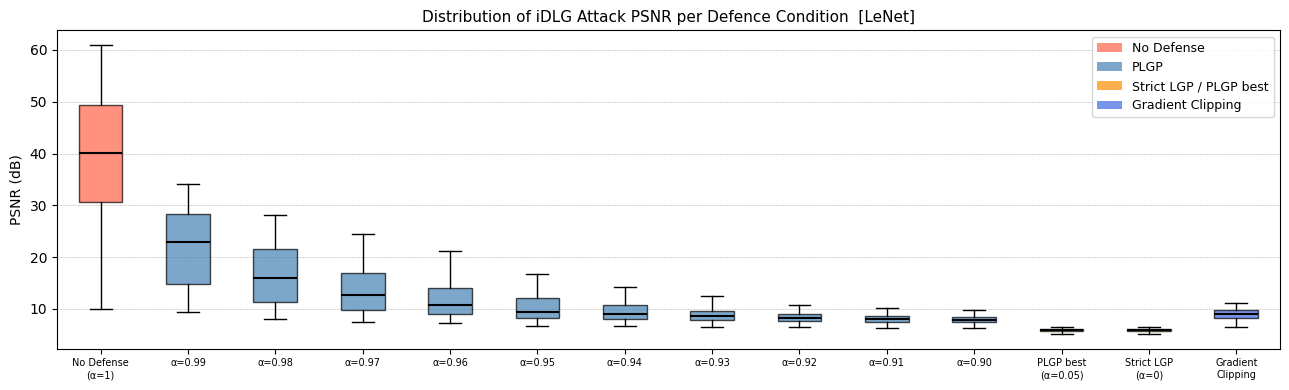

In [2]:
CONDITIONS = [
    ('prune', 1.00, 'No Defense\n(α=1)'),
    ('prune', 0.99, 'α=0.99'),
    ('prune', 0.98, 'α=0.98'),
    ('prune', 0.97, 'α=0.97'),
    ('prune', 0.96, 'α=0.96'),
    ('prune', 0.95, 'α=0.95'),
    ('prune', 0.94, 'α=0.94'),
    ('prune', 0.93, 'α=0.93'),
    ('prune', 0.92, 'α=0.92'),
    ('prune', 0.91, 'α=0.91'),
    ('prune', 0.90, 'α=0.90'),
    ('prune', 0.05, 'PLGP best\n(α=0.05)'),
    ('prune', 0.00, 'Strict LGP\n(α=0)'),
    ('clip',  1.00, 'Gradient\nClipping'),
]

data, labels, colors = [], [], []
for method, alpha, label in CONDITIONS:
    vals = get_best_psnr_per_image(method, alpha)
    if vals:
        data.append(vals)
        labels.append(label)
        if method == 'clip':
            colors.append('royalblue')
        elif alpha == 1.0:
            colors.append('tomato')
        elif alpha <= 0.05:
            colors.append('darkorange')
        else:
            colors.append('steelblue')

fig, ax = plt.subplots(figsize=(13, 4))
bp = ax.boxplot(data, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel('PSNR (dB)', fontsize=FS)
ax.set_title('Distribution of iDLG Attack PSNR per Defence Condition  [LeNet]', fontsize=FS+1)
ax.grid(True, axis='y', linestyle='--', linewidth=0.4)
ax.tick_params(axis='y', labelsize=FS)

legend_elements = [
    Patch(facecolor='tomato',     alpha=0.7, label='No Defense'),
    Patch(facecolor='steelblue',  alpha=0.7, label='PLGP'),
    Patch(facecolor='darkorange', alpha=0.7, label='Strict LGP / PLGP best'),
    Patch(facecolor='royalblue',  alpha=0.7, label='Gradient Clipping'),
]
ax.legend(handles=legend_elements, fontsize=FS-1)
plt.tight_layout()
plt.show()

## Convergence Rate: Iterations to Reach PSNR Thresholds

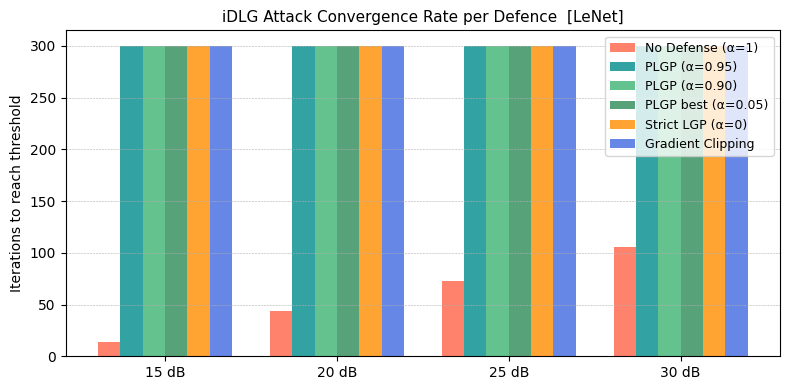

In [3]:
THRESHOLDS = [15, 20, 25, 30]

HIGHLIGHT = [
    ('prune', 1.00, 'No Defense (α=1)',   'tomato'),
    ('prune', 0.95, 'PLGP (α=0.95)',      'darkcyan'),
    ('prune', 0.90, 'PLGP (α=0.90)',      'mediumseagreen'),
    ('prune', 0.05, 'PLGP best (α=0.05)', 'seagreen'),
    ('prune', 0.00, 'Strict LGP (α=0)',   'darkorange'),
    ('clip',  1.00, 'Gradient Clipping',  'royalblue'),
]

x       = np.arange(len(THRESHOLDS))
width   = 0.13
n       = len(HIGHLIGHT)
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * width

fig, ax = plt.subplots(figsize=(8, 4))
for i, (method, alpha, label, color) in enumerate(HIGHLIGHT):
    curve = get_mean_psnr_curve(method, alpha)
    iters = [iters_to_threshold(curve, t) for t in THRESHOLDS]
    ax.bar(x + offsets[i], iters, width, label=label, color=color, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f'{t} dB' for t in THRESHOLDS], fontsize=FS)
ax.set_ylabel('Iterations to reach threshold', fontsize=FS)
ax.set_title('iDLG Attack Convergence Rate per Defence  [LeNet]', fontsize=FS+1)
ax.legend(fontsize=FS-1)
ax.grid(True, axis='y', linestyle='--', linewidth=0.4)
ax.tick_params(labelsize=FS)
plt.tight_layout()
plt.show()